# EDA orientée NLP du corpus de travail

Cette analyse ne cherche pas à décrire un jeu de données, elle cherche à **fixer les réglages
d'un entraînement Seq2Seq** et à savoir ce qu'ils coûtent. Chaque section pose une question dont
la réponse change une valeur de configuration ou une conclusion du rapport. Une analyse dont la
réponse ne changerait rien n'a pas sa place ici.

Le corpus est **CNN/DailyMail**, configuration `3.0.0`, celle de See et al. 2017 : l'article
complet d'un côté, les puces de highlights de l'autre, entités nommées en clair. La référence y
fait trois à quatre phrases, ce qui distingue la tâche du résumé extrême et fixe deux réglages
mesurés plus bas : le plafond de tokens cible et le budget de décodage.

Un point de lecture à poser d'emblée. Le ROUGE-L rapporté ici n'est pas le ROUGE-Lsum que la
littérature publie sur ce corpus : `rougeLsum` découpe la référence sur ses sauts de ligne et
apparie chaque phrase séparément, quand ROUGE-L exige une seule sous-séquence traversant toute la
paire. Sur une référence de trois à quatre phrases, la seconde mesure est nettement plus sévère.
Toutes les comparaisons de ce projet sont internes, même métrique et même jeu de test pour tous
les modèles ; aucune n'est à confronter à un chiffre publié.

Le « 100 % » désigne partout les 20 000 exemples du corpus de travail figé, jamais les
287 113 exemples d'entraînement de CNN/DailyMail complet.

## Ce que le notebook ne fait pas

Il ne recalcule rien que la chaîne de données ait déjà mesuré. Les distributions de longueur, les
comptes de troncature et les sommes de contrôle sont produits par `python -m src.data.build` et
écrits à côté du corpus. Les relire ici, plutôt que les refaire, est ce qui garantit que le
notebook et l'entraînement parlent du même corpus.

Il ne trace pas non plus de graphique décoratif. Les seules figures présentes sont celles dont la
forme, et pas seulement la moyenne, change une décision.

> Les sorties de ce notebook sont retirées à chaque commit par le hook `nbstripout`. Les chiffres
> qui comptent sont donc recopiés dans la documentation, page **Données**, où ils sont durables.

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt

from src.data.config import load_pipeline_config
from src.data.dataset import load_manifest, load_split, load_training_proportion
from src.data.tokenize import build_tokenizer, token_lengths
from src.data.validate import require_no_leakage, validate_split

CONFIG = load_pipeline_config(REPO_ROOT / "configs" / "data" / "cnn_dailymail.yaml")
PROCESSED = REPO_ROOT / "data" / "processed" / "cnn_dailymail"

plt.rcParams["figure.figsize"] = (9.0, 4.0)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = ":"

SCRATCH_COLOUR = "#c1440e"
PRETRAINED_COLOUR = "#1f4e79"

## 1. Ce que le corpus déclare de lui-même

Avant de mesurer quoi que ce soit, on lit ce que la chaîne de préparation a écrit. Le manifeste
porte une somme de contrôle par split et par proportion : c'est ce qui permet d'affirmer que le
corpus analysé ici est celui qui a servi aux neuf entraînements, et pas une reconstruction
approchante.

In [2]:
manifest = load_manifest(PROCESSED)

print(f"corpus            {manifest.name} (source : {manifest.source_dataset})")
print(f"version           {manifest.dataset_version}")
print(f"graine du tirage  {manifest.seed}")
print(f"tokenizer         {manifest.tokenizer}")
print()
for split, size in manifest.splits.items():
    print(f"{split:<12} {size:>6} exemples   sha256 {manifest.split_checksums[split][:16]}...")

corpus            xsum (source : EdinburghNLP/xsum)
version           259d8397ce784da564cb9d852fce7106213585fa632986e20109eab4c26d97c3
graine du tirage  42
tokenizer         t5-small

test           1000 exemples   sha256 c4e301417202efbe...
train         20000 exemples   sha256 4adfb74282821163...
validation     1000 exemples   sha256 de09de42bbaa9cec...


## 2. Volume disponible

La première question est aussi la plus simple : combien d'exemples, et de quoi dispose-t-on pour
chaque proportion de l'ablation ?

Ce qui compte ici n'est pas seulement le total, c'est **l'emboîtement**. Le sous-ensemble à 10 %
doit être un préfixe de celui à 50 %, lui-même préfixe de celui à 100 %. Sans cette propriété, un
écart entre deux points de la courbe mélangerait l'effet de la taille et celui de la composition
de l'échantillon, et rien dans le résultat ne permettrait de séparer les deux.

In [3]:
splits = {name: load_split(PROCESSED, name) for name in ("train", "validation", "test")}
proportions = {percentage: load_training_proportion(PROCESSED, percentage) for percentage in (10, 50, 100)}

for name, examples in splits.items():
    print(f"{name:<12} {len(examples):>6}")

print()
identifiers = {
    percentage: [example.example_id for example in examples]
    for percentage, examples in proportions.items()
}
for percentage, examples in proportions.items():
    print(f"{percentage:>4} % du corpus d'entrainement : {len(examples):>6} exemples")

print()
print("10 % est un prefixe de 50 %  :", identifiers[50][: len(identifiers[10])] == identifiers[10])
print("50 % est un prefixe de 100 % :", identifiers[100][: len(identifiers[50])] == identifiers[50])

train         20000
validation     1000
test           1000

  10 % du corpus d'entrainement :   2000 exemples
  50 % du corpus d'entrainement :  10000 exemples
 100 % du corpus d'entrainement :  20000 exemples

10 % est un prefixe de 50 %  : True
50 % est un prefixe de 100 % : True


## 3. Qualité : valeurs manquantes, doublons, fuite entre splits

Trois défauts se ressemblent sur un tableau de bord et n'ont pas du tout les mêmes conséquences.

Un champ vide casse l'entraînement ou, pire, apprend au modèle à produire du vide. Un doublon
intra-split biaise la pondération d'un exemple. Un document présent à la fois dans
l'entraînement et dans le test invalide la mesure entière : le modèle est alors interrogé sur ce
qu'il a mémorisé.

La chaîne de données applique déjà ces contrôles au moment de la construction et refuse d'écrire
un corpus sale. Les rejouer ici sert à montrer le résultat, pas à le découvrir.

In [4]:
for name, examples in splits.items():
    report = validate_split(name, examples)
    print(report.describe())
    print(f"   propre : {report.is_clean}")

print()
try:
    require_no_leakage(splits["train"], splits["validation"], splits["test"])
    print("Aucun chevauchement entre les splits, ni par identifiant ni par document.")
except Exception as error:
    print("FUITE :", error)

train: 20000 examples, 0 empty documents, 0 empty summaries, 0 duplicate ids, 2 duplicate documents, 1 summaries longer than their document
   propre : True
validation: 1000 examples, 0 empty documents, 0 empty summaries, 0 duplicate ids, 0 duplicate documents, 0 summaries longer than their document
   propre : True
test: 1000 examples, 0 empty documents, 0 empty summaries, 0 duplicate ids, 0 duplicate documents, 0 summaries longer than their document
   propre : True

Aucun chevauchement entre les splits, ni par identifiant ni par document.


**Ce que la mesure donne.** Aucun champ vide, aucun identifiant dupliqué, aucun chevauchement
entre les splits. Deux documents apparaissent deux fois dans l'entraînement, et un exemple porte
un résumé plus long que son document.

Ces trois cas sont signalés et conservés. Les retirer serait un nettoyage silencieux du corpus de
référence, qui rendrait les scores incomparables avec la littérature XSum. Deux doublons sur
20 000 pèsent 0,01 % de la pondération, et le résumé plus long que son document est un exemple
authentique du corpus, pas une erreur de chargement.

## 4. Longueur des documents et des résumés

C'est la section qui fixe `max_source_tokens` et `max_target_tokens`. Trois unités coexistent et
elles ne disent pas la même chose :

- les **caractères** mesurent le texte brut,
- les **mots** donnent une intuition lisible,
- les **tokens** sont la seule unité que le modèle voit, et la seule qui coûte du calcul.

Un plafond se choisit en tokens. Les deux autres unités servent à comprendre ce que le plafond
coupe réellement.

In [5]:
statistics = json.loads((PROCESSED / "statistics.json").read_text(encoding="utf-8"))

header = f"{'split':<12}{'unite':<14}{'moyenne':>10}{'mediane':>10}{'p95':>10}{'max':>10}"
print(header)
print("-" * len(header))
for split in ("train", "validation", "test"):
    words = statistics["characters_and_words"][split]
    tokens = statistics["tokens"][split]
    for label, block in (
        ("mots source", words["source_words"]),
        ("tokens source", tokens["source_tokens"]),
        ("mots cible", words["target_words"]),
        ("tokens cible", tokens["target_tokens"]),
    ):
        print(
            f"{split:<12}{label:<14}{block['mean']:>10.1f}{block['median']:>10.1f}"
            f"{block['p95']:>10.1f}{block['maximum']:>10}"
        )
    print()

split       unite            moyenne   mediane       p95       max
------------------------------------------------------------------
train       mots source        373.2     296.5     924.0      3487
train       tokens source      525.2     414.0    1305.0      6191
train       mots cible          21.1      21.0      30.0        70
train       tokens cible        30.3      30.0      43.0       133

validation  mots source        378.9     287.5     935.0      2161
validation  tokens source      533.2     403.5    1329.8      3066
validation  mots cible          21.2      21.0      29.0        49
validation  tokens cible        30.6      30.0      43.0       105

test        mots source        384.4     302.0     980.0      2084
test        tokens source      535.2     421.5    1380.3      3152
test        mots cible          21.3      21.0      30.0        49
test        tokens cible        30.6      30.0      42.0        77



### Ce que le plafond coupe

Les statistiques ci-dessus sont mesurées **sans troncature**. Le tableau suivant chiffre l'effet du
plafond retenu et de quatre alternatives, sur deux axes qui ne se confondent pas : la part des
documents touchés, et la part du texte réellement conservée.

Un document coupé n'est pas un document perdu. Ce qui compte est la proportion de contenu qui
atteint l'encodeur.

In [6]:
tokenizer = build_tokenizer(CONFIG.tokenizer.hf_id)
source_lengths, target_lengths = token_lengths(splits["train"], tokenizer, CONFIG.tokenizer)

cap_source = CONFIG.tokenizer.max_source_tokens
cap_target = CONFIG.tokenizer.max_target_tokens
total_source_tokens = sum(source_lengths)

print(f"plafond retenu : {cap_source} tokens source, {cap_target} tokens cible")
print()
print(f"{'plafond':>9}{'documents coupes':>20}{'texte conserve':>18}{'cout encodeur':>16}")
print("-" * 63)
for cap in (256, 512, 768, 1024, 1536):
    cut = sum(1 for length in source_lengths if length > cap)
    kept = sum(min(length, cap) for length in source_lengths)
    relative_cost = (cap / cap_source) ** 2
    marker = "  <-- retenu" if cap == cap_source else ""
    print(
        f"{cap:>9}{cut / len(source_lengths):>19.1%}{kept / total_source_tokens:>18.1%}"
        f"{relative_cost:>15.1f}x{marker}"
    )

over_target = sum(1 for length in target_lengths if length > cap_target)
print()
print(f"cibles coupees a {cap_target} tokens : {over_target}/{len(target_lengths)} = {over_target / len(target_lengths):.2%}")

Token indices sequence length is longer than the specified maximum sequence length for this model (692 > 512). Running this sequence through the model will result in indexing errors


plafond retenu : 512 tokens source, 64 tokens cible

  plafond    documents coupes    texte conserve   cout encodeur
---------------------------------------------------------------
      256              74.3%             44.0%            0.2x
      512              38.4%             70.9%            1.0x  <-- retenu
      768              20.3%             84.7%            2.2x
     1024              10.8%             92.1%            4.0x
     1536               2.5%             97.8%            9.0x

cibles coupees a 64 tokens : 84/20000 = 0.42%


**Décision, et son prix.** Le plafond de 512 tokens coupe **38 % des documents** et conserve
**71 % du texte source**. C'est un chiffre élevé, et il est assumé plutôt que masqué : l'attention
coûte le carré de la longueur, donc passer à 1 024 tokens pour récupérer 21 points de texte
multiplierait par quatre le coût de l'encodeur. Sur le matériel de ce projet, cela transformerait
une campagne de deux heures en une campagne de huit.

La conséquence doit être lue avec les résultats : **les deux familles de modèles subissent
exactement la même troncature**, donc la comparaison reste valide. Ce qui est perdu est une part
du plafond de performance atteignable, pas l'équité de la comparaison.

Le plafond des cibles, lui, ne coupe que 0,42 % des résumés. Il est essentiellement gratuit, ce
qui est attendu d'un corpus dont les références tiennent en une phrase.

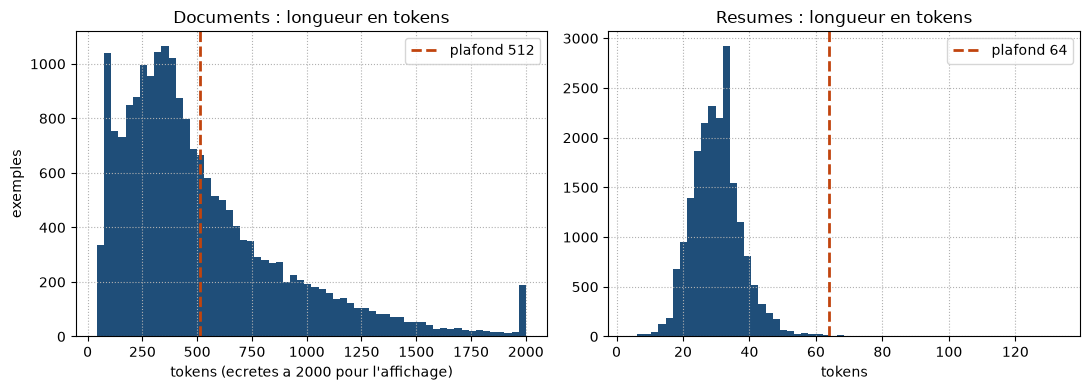

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

axes[0].hist([min(length, 2000) for length in source_lengths], bins=60, color=PRETRAINED_COLOUR)
axes[0].axvline(cap_source, color=SCRATCH_COLOUR, linestyle="--", linewidth=2, label=f"plafond {cap_source}")
axes[0].set_title("Documents : longueur en tokens")
axes[0].set_xlabel("tokens (ecretes a 2000 pour l'affichage)")
axes[0].set_ylabel("exemples")
axes[0].legend()

axes[1].hist(target_lengths, bins=60, color=PRETRAINED_COLOUR)
axes[1].axvline(cap_target, color=SCRATCH_COLOUR, linestyle="--", linewidth=2, label=f"plafond {cap_target}")
axes[1].set_title("Resumes : longueur en tokens")
axes[1].set_xlabel("tokens")
axes[1].legend()

figure.tight_layout()
plt.show()

Les deux distributions n'ont pas la même forme, et c'est le point de cette figure.

Celle des documents est très asymétrique, avec une queue qui s'étend jusqu'à 6 191 tokens : la
moyenne à 525 tokens ne décrit personne. Celle des résumés est resserrée autour de 30 tokens et
quasi symétrique. Un modèle de résumé sur ce corpus doit donc encaisser une entrée de longueur
très variable et produire une sortie de longueur presque constante.

C'est aussi ce qui justifie le regroupement par longueur pendant l'entraînement : avec une telle
dispersion à l'entrée, un batch tiré au hasard est majoritairement composé de remplissage.

## 5. Ratio de compression

Le ratio résumé sur document dit quelle tâche le modèle doit apprendre. Un ratio de 0,5 est une
reformulation, un ratio de 0,1 est une réécriture qui jette neuf dixièmes de l'entrée.

In [8]:
ratios = sorted(target / source for source, target in zip(source_lengths, target_lengths, strict=False) if source)

percentile = lambda fraction: ratios[int(fraction * (len(ratios) - 1))]
print(f"moyenne  {sum(ratios) / len(ratios):.4f}")
print(f"mediane  {percentile(0.50):.4f}")
print(f"p5       {percentile(0.05):.4f}")
print(f"p95      {percentile(0.95):.4f}")
print()
print(f"compression mediane : le resume fait {percentile(0.50) * 100:.1f} % du document")

moyenne  0.0980
mediane  0.0718
p5       0.0220
p95      0.2817

compression mediane : le resume fait 7.2 % du document


**Ce que cela impose.** Un ratio médian de 7 % place la tâche du côté du résumé abstractif
extrême. Deux conséquences suivent directement.

La première touche la métrique : un ROUGE-L de 0,23 sur XSum n'est pas comparable à un ROUGE-L de
0,35 publié sur CNN/DailyMail, parce que la seconde tâche autorise à recopier des phrases entières
du document. Toute lecture des résultats qui ignore cela compare deux échelles différentes.

La seconde touche le modèle from scratch : à ce niveau de compression, la copie ne suffit pas. Le
modèle doit produire une phrase qui n'existe pas dans l'entrée, ce qui est précisément ce qu'un
Transformer entraîné sur 20 000 exemples a le plus de mal à faire.

## 6. Vocabulaire : la section qui décide du modèle from scratch

C'est l'analyse la plus importante du notebook pour ce projet, et celle qu'une EDA généraliste
n'aurait pas faite.

Le modèle from scratch et la baseline pré-entraînée partagent le tokenizer `t5-small`. Pour la
baseline, c'est un choix neutre : ses embeddings sont déjà entraînés. Pour le modèle from scratch,
la table d'embedding est **le plus gros bloc de paramètres du modèle**, et chacune de ses lignes
doit être apprise à partir de rien, uniquement sur les occurrences présentes dans le corpus.

La question devient donc : combien de lignes de cette table le corpus permet-il réellement
d'apprendre ?

In [9]:
encoded_sources = tokenizer(
    [CONFIG.tokenizer.source_prefix + example.source for example in splits["train"]],
    truncation=False,
)["input_ids"]
encoded_targets = tokenizer([example.target for example in splits["train"]], truncation=False)["input_ids"]

counts: Counter[int] = Counter()
for identifiers_ in encoded_sources:
    counts.update(identifiers_)
for identifiers_ in encoded_targets:
    counts.update(identifiers_)

vocabulary = len(tokenizer)
observed = len(counts)
occurrences = sum(counts.values())

print(f"entrees du tokenizer          {vocabulary:>10,}")
print(f"types observes                {observed:>10,}  ({observed / vocabulary:.1%})")
print(f"jamais observes               {vocabulary - observed:>10,}  ({1 - observed / vocabulary:.1%})")
print(f"occurrences totales           {occurrences:>10,}")
print()
print(f"hapax (1 occurrence)          {sum(1 for c in counts.values() if c == 1):>10,}")
print(f"rares (< 10 occurrences)      {sum(1 for c in counts.values() if c < 10):>10,}")

entrees du tokenizer              32,100
types observes                    23,458  (73.1%)
jamais observes                    8,642  (26.9%)
occurrences totales           11,111,813

hapax (1 occurrence)                 867
rares (< 10 occurrences)           4,199


In [10]:
ordered = counts.most_common()

print("Concentration des occurrences :")
cumulative = 0
targets = [0.5, 0.9, 0.95, 0.99]
index_of = {}
for index, (_, count) in enumerate(ordered, start=1):
    cumulative += count
    while targets and cumulative >= targets[0] * occurrences:
        index_of[targets[0]] = index
        targets.pop(0)

for fraction, index in index_of.items():
    print(f"  {fraction:>5.0%} des occurrences tiennent dans {index:>6,} types ({index / vocabulary:.1%} de la table)")

Concentration des occurrences :
    50% des occurrences tiennent dans    100 types (0.3% de la table)
    90% des occurrences tiennent dans  4,596 types (14.3% de la table)
    95% des occurrences tiennent dans  7,795 types (24.3% de la table)
    99% des occurrences tiennent dans 14,510 types (45.2% de la table)


In [11]:
d_model = 256
embedding_parameters = vocabulary * d_model
dead_parameters = (vocabulary - observed) * d_model
model_parameters = 15_591_424  # scratch_100, releve dans reports/results/scratch_100/run.json

print(f"table d'embedding      {vocabulary:>7,} x {d_model} = {embedding_parameters:>12,} parametres")
print(f"modele complet                          {model_parameters:>12,} parametres")
print(f"part de l'embedding                     {embedding_parameters / model_parameters:>12.1%}")
print()
print(f"lignes jamais mises a jour              {dead_parameters:>12,} parametres")
print(f"soit                                    {dead_parameters / model_parameters:>12.1%} du modele")

table d'embedding       32,100 x 256 =    8,217,600 parametres
modele complet                            15,591,424 parametres
part de l'embedding                            52.7%

lignes jamais mises a jour                 2,212,352 parametres
soit                                           14.2% du modele


**Le résultat.** Sur 32 100 entrées du tokenizer, **23 458 apparaissent au moins une fois** dans le
corpus d'entraînement, soit 73 %. Les 8 642 restantes correspondent à 2,2 millions de paramètres,
**14 % du modèle from scratch, qui ne reçoivent jamais le moindre gradient**. Ils sont initialisés
au hasard, sauvegardés dans chaque checkpoint, et n'apprennent rien.

Pire, la concentration est extrême : **50 % des occurrences tiennent dans 100 types**, et il faut
14 510 types pour couvrir 99 % du texte. Les 9 000 types les plus rares sont vus moins de dix fois
chacun ; leur ligne d'embedding est mise à jour trop peu de fois pour valoir mieux que du bruit.

C'est l'explication mécanique du résultat de l'ablation d'architecture : la table d'embedding pèse
53 % du modèle à 4 couches, donc ajouter des couches fait varier une minorité des paramètres,
pendant que la majorité reste sous-entraînée. **Le levier n'est pas la profondeur, c'est le
vocabulaire.** Un tokenizer réduit au corpus, de l'ordre de 8 000 entrées, libérerait environ
6 millions de paramètres, mais casserait le partage du tokenizer avec la baseline et donc
l'équité de la comparaison. C'est un compromis explicite, pas un oubli.

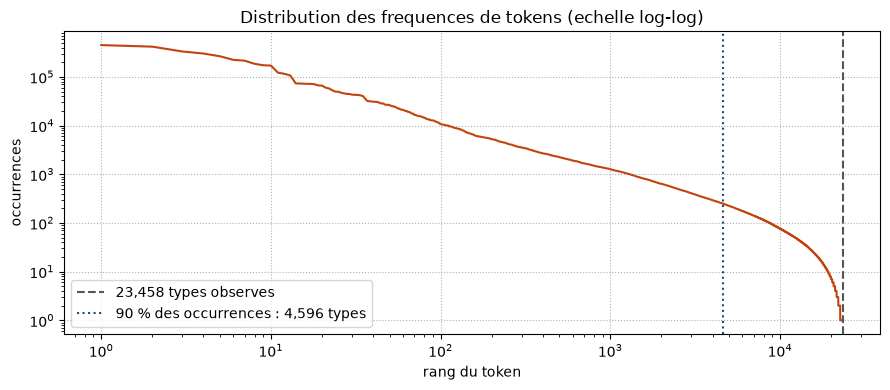

In [12]:
figure, axes = plt.subplots(figsize=(9.0, 4.0))

frequencies = [count for _, count in ordered]
axes.loglog(range(1, len(frequencies) + 1), frequencies, color=SCRATCH_COLOUR, linewidth=1.5)
axes.axvline(observed, color="#555555", linestyle="--", label=f"{observed:,} types observes")
axes.axvline(index_of[0.9], color=PRETRAINED_COLOUR, linestyle=":", label=f"90 % des occurrences : {index_of[0.9]:,} types")
axes.set_title("Distribution des frequences de tokens (echelle log-log)")
axes.set_xlabel("rang du token")
axes.set_ylabel("occurrences")
axes.legend()

figure.tight_layout()
plt.show()

La droite quasi parfaite sur une échelle log-log est une loi de Zipf, ce qui est attendu. Ce qui
l'est moins, et qui compte ici, est **l'endroit où la courbe s'effondre** : au-delà du rang 15 000,
les fréquences tombent sous dix occurrences. Tout ce qui est à droite de ce point est une ligne
d'embedding que ce corpus ne peut pas apprendre.

## 7. Fragmentation en sous-mots

Le tokenizer `t5-small` est un SentencePiece : il ne produit jamais de token inconnu, il découpe
en morceaux. L'absence d'`<unk>` n'est donc pas une bonne nouvelle en soi, elle déplace le
problème. Le taux de fragmentation dit combien.

In [13]:
source_words = sum(len(example.source.split()) for example in splits["train"])
source_pieces = sum(len(identifiers_) for identifiers_ in encoded_sources)
target_words = sum(len(example.target.split()) for example in splits["train"])
target_pieces = sum(len(identifiers_) for identifiers_ in encoded_targets)

print(f"documents : {source_pieces / source_words:.3f} tokens par mot")
print(f"resumes   : {target_pieces / target_words:.3f} tokens par mot")
print()
print(f"un plafond de {cap_source} tokens vaut donc environ {cap_source / (source_pieces / source_words):.0f} mots")

documents : 1.407 tokens par mot
resumes   : 1.436 tokens par mot

un plafond de 512 tokens vaut donc environ 364 mots


**1,41 token par mot** est un taux sain pour de l'anglais journalistique : la majorité des mots
courants tiennent en un seul morceau, la fragmentation se concentre sur les noms propres. Cela
signifie aussi que le plafond de 512 tokens correspond à environ **364 mots**, ce qui recoupe la
médiane de 296 mots par document et confirme que la coupure touche la queue de distribution, pas
le corps.

## 8. Exemples extrêmes

Les deux bouts de la distribution ne sont pas des anomalies à retirer : ils disent ce que le
modèle doit encaisser dans le pire cas.

In [14]:
pairs = sorted(zip(source_lengths, splits["train"], strict=False), key=lambda item: item[0])

for label, (length, example) in (("Le plus court", pairs[0]), ("Le plus long", pairs[-1])):
    print(f"--- {label} : {length} tokens, {len(example.source.split())} mots ---")
    print("document :", example.source[:300].replace(chr(10), " "), "...")
    print("resume   :", example.target)
    print()

--- Le plus court : 43 tokens, 33 mots ---
document : Police Scotland said the incident happened just before 18:30 on Monday in Jamaica Street. He was taken to the Queen Elizabeth University Hospital in Glasgow. His injuries are not thought to be life-threatening. ...
resume   : A three-year-old boy is being treated in hospital after being hit by a bus in Glasgow city centre.

--- Le plus long : 6191 tokens, 2617 mots ---
document : Signings confirmed in May and June can be found on previous transfer pages. For all the latest rumours, check out the Gossip page and for all the manager ins and outs for July, see the current manager's list. Transfers organised into Premier League, Football League and Scottish Premiership by the bu ...
resume   : The summer transfer window opened in England, Scotland and Wales on Wednesday, 1 July at 00:00 BST and will close again on Tuesday, 1 September, at 18:00 BST.



Le document le plus long, 6 191 tokens, est une page de rumeurs de mercato : une liste, pas un
article. Son résumé de référence ne peut être déduit d'aucune de ses phrases. C'est le type
d'exemple pour lequel la troncature à 512 tokens ne dégrade rien, parce que rien d'exploitable
n'était présent au-delà non plus.

Le plus court, 43 tokens, est un fait divers de trois phrases, et son résumé en reprend la
substance. C'est le cas favorable, et c'est aussi celui où un modèle from scratch a une chance
réelle.

Ces deux exemples sont conservés dans le corpus. Les retirer relèverait la moyenne pour avoir
écarté ce qui est difficile.

## 9. Budget d'entraînement

Dernière question, celle qui dimensionne la campagne : combien de tokens chaque proportion de
l'ablation représente-t-elle réellement, une fois la troncature appliquée ?

In [15]:
print(f"{'proportion':>12}{'exemples':>11}{'tokens source':>16}{'tokens cible':>15}")
print("-" * 54)
for percentage, examples in proportions.items():
    size = len(examples)
    source_budget = sum(min(length, cap_source) for length in source_lengths[:size])
    target_budget = sum(min(length, cap_target) for length in target_lengths[:size])
    print(f"{percentage:>11} %{size:>11,}{source_budget:>16,}{target_budget:>15,}")

  proportion   exemples   tokens source   tokens cible
------------------------------------------------------
         10 %      2,000         743,100         60,259
         50 %     10,000       3,714,850        302,856
        100 %     20,000       7,452,465        605,329


**Ce que cela veut dire pour l'ablation.** Le point à 10 % ne représente que 743 000 tokens source.
À titre de repère, `t5-small` a été pré-entraîné sur de l'ordre de 34 milliards de tokens, soit
environ **45 000 fois plus**. Le modèle from scratch part donc de zéro avec quatre ordres de
grandeur de moins de texte que ce dont dispose déjà la baseline avant même de commencer.

Ce chiffre, mesuré ici, est la meilleure explication de la forme de la courbe du rapport : l'écart
entre les deux familles ne se referme pas parce qu'il ne s'agit pas du même budget de données, et
multiplier par dix un corpus de 20 000 exemples ne change pas l'ordre de grandeur.

## Ce que l'EDA a fixé

| Constat | Décision |
| --- | --- |
| p95 des documents à 1 305 tokens, coût quadratique de l'attention | `max_source_tokens = 512`, 38 % de documents coupés, 71 % du texte gardé |
| p95 des résumés à 43 tokens | `max_target_tokens = 64`, 0,42 % de cibles coupées |
| Dispersion extrême des longueurs d'entrée | regroupement par longueur pour limiter le remplissage |
| 73 % du vocabulaire observé, 50 % des occurrences dans 100 types | le levier du modèle from scratch est le vocabulaire, pas la profondeur |
| Ratio de compression médian de 7 % | tâche abstractive, ROUGE non comparable à CNN/DailyMail |
| 743 000 tokens à 10 % du corpus | l'écart avec le pré-entraîné n'est pas comblable par les données |
| Aucune fuite, sous-ensembles emboîtés | l'ablation mesure la taille, pas la composition |